In [4]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [23]:
orders = pd.read_csv("../data/orders.csv")
products = pd.read_csv("../data/products.csv")
returns = pd.read_csv("../data/returns.csv")
shipments = pd.read_csv("../data/shipments.csv")
order_items = pd.read_csv("../data/order_items.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40792\771313658.py:5: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


In [55]:
returns.head(10)
returns.sort_values(by='product_id')

,product_id,return_reason,return_quantity,refund_amount
22729,3,changed_mind,7,65029.45
39837,3,changed_mind,8,74960.16
22796,3,not_as_described,4,37875.21
22849,3,wrong_size,1,10737.70
36852,3,wrong_size,2,21053.56
...,...,...,...,...
20206,2412,late_delivery,2,1901.98
20186,2412,changed_mind,2,1950.52
32907,2412,defective,1,1153.54
26687,2412,defective,3,3732.17


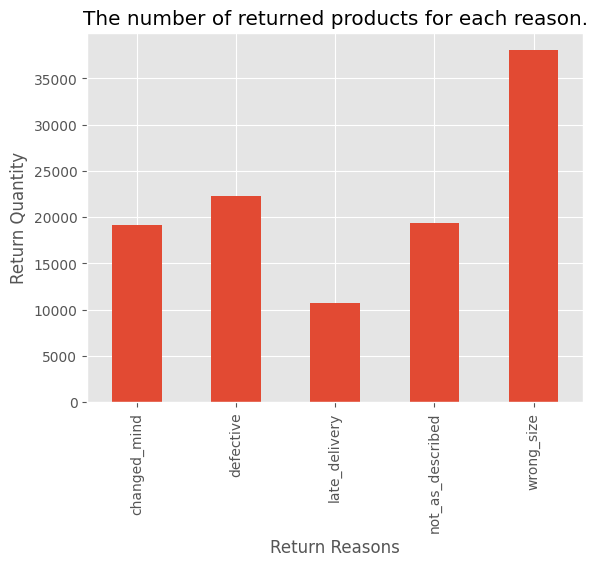

In [33]:
returns = returns[['product_id','return_reason','return_quantity','refund_amount']]
ax = returns.groupby('return_reason').sum()['return_quantity'].plot(kind = 'bar',title ='The number of returned products for each reason.')
ax.set_xlabel("Return Reasons")
ax.set_ylabel("Return Quantity")
plt.show()


Có thể thấy, lý do wrong size là lý do khiến cho khách hàng phải trả lại hàng nhiều nhất (cũng là có số tiền refund lớn nhất). Tại sao? Và sản phẩm nào lại wrong size nhiều nhất?

In [41]:
products.head(10)
products.shape

(2412, 8)

In [57]:
products_returns = pd.merge(left = products, right = returns, on = 'product_id', how = 'inner')
products_returns = products_returns[products_returns['return_reason'] == 'wrong_size'].copy()
products_returns.shape

(13967, 11)